In [72]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph  , START , END
from dotenv import load_dotenv
from typing import TypedDict
load_dotenv()

True

In [73]:
model = ChatGoogleGenerativeAI(model = 'gemini-2.5-flash')

In [74]:
from pydantic import BaseModel , Field


class evalstructure(BaseModel):
    feedback: str = Field(description = " Detailed feedbcak on essay" )
    score: int = Field(description = "Score out of 10" , ge = 0 , le = 10)

In [75]:
Struct_model = model.with_structured_output(evalstructure)

In [76]:
class LLMstate(TypedDict):
    essay : str

    COTFeedback : str
    COTScore: int

    DOAFeedback: str
    DOAScore : int

    LanguageFeedback : str
    LanguageScore: int

    FinalFB : str
    FinalScore : int

In [77]:
graph = StateGraph(LLMstate)

In [78]:
def COTcalculator(state:LLMstate) -> LLMstate:
    essay = state["essay"]
    prompt = f"Return a dictionary with keys COTfeedback and COTscore where COTfeedback -> Text feedback on essay on basis of clarity of thought of the essay and COTscore -> Score on scale from 1-10 on basis of clarity of thought of essay. the essay is:{essay}"
    result = Struct_model.invoke(prompt)

    return {"COTFeedback": result.feedback , "COTScore" : result.score}

In [79]:
def DOAcalculator(state:LLMstate) -> LLMstate:
    essay = state["essay"]
    prompt = f"Return a dictionary with keys DOAfeedback and DOAscore where DOAfeedback -> Text feedback on essay on basis of Depth of analysis  of the essay and DOAscore -> Score on scale from 1-10 on basis of Depth of analysis of essay. the essay is:{essay}"
    result = Struct_model.invoke(prompt)

    return {"DOAFeedback": result.feedback , "DOAScore" : result.score}

In [80]:
def Languagecalculator(state:LLMstate) -> LLMstate:
    essay = state["essay"]
    prompt = f"Return a dictionary with keys Languagefeedback and Languagescore where Languagefeedback -> Text feedback on essay on basis of Language of the essay and Languagescore -> Score on scale from 1-10 on basis of Language of essay. the essay is:{essay}"
    result = Struct_model.invoke(prompt)

    return {"LanguageFeedback": result.feedback , "LanguageScore" : result.score}

In [81]:

def FinalCal (state: LLMstate) -> LLMstate:
    codf = state["COTFeedback"]
    doa = state["DOAFeedback"]
    lang = state["LanguageFeedback"]
    prompt = f"I am Providing you COTFeedback ie {codf} . Depth of analysis feedback is {doa} and at last there is language feedback that is {lang} now give me the final feedback that should have all three feedbacks"
    state["FinalFB"] = model.invoke(prompt)
    state["FinalScore"  ] = state["COTScore"]+state["LanguageScore"]+state["DOAScore"]/3

    return state

In [82]:
graph.add_node("COTcalculator" , COTcalculator)
graph.add_node("DOAcalculator" , DOAcalculator)
graph.add_node("Languagecalculator" , Languagecalculator)
graph.add_node("FinalCal" , FinalCal)

In [83]:
graph.add_edge(START  , "COTcalculator")
graph.add_edge(START , "DOAcalculator")
graph.add_edge(START , "Languagecalculator")
graph.add_edge("COTcalculator" , "FinalCal")
graph.add_edge("DOAcalculator" , "FinalCal")
graph.add_edge("Languagecalculator" , "FinalCal")
graph.add_edge("FinalCal", END)

workflow = graph.compile()

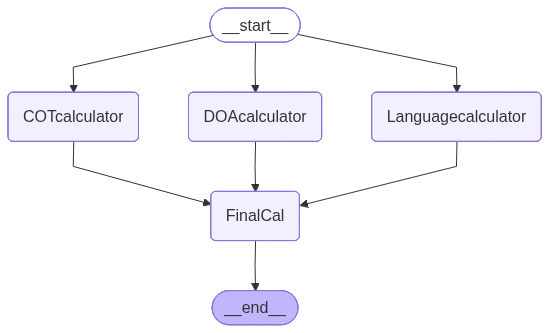

In [84]:
workflow

In [85]:
initial_state = {"essay":"""The Importance of Daily Exercise"

Introduction: Maintaining a daily exercise routine is essential for a healthy lifestyle, offering both physical and mental benefits. Regular activity strengthens the heart, improves muscle tone, and releases endorphins that boost mood. Therefore, incorporating even thirty minutes of movement into one's day is a critical investment in long-term well-being. 

Body Paragraph: Physically, exercise helps regulate weight and reduces the risk of chronic diseases such as diabetes and hypertension. Studies show that consistent aerobic activity improves cardiovascular efficiency, allowing the body to function more effectively. Additionally, strength training builds bone density, which is crucial for aging populations.

Conclusion: In summary, daily exercise is not just about appearance but about sustaining overall health. By prioritizing physical activity, individuals can enhance their quality of life and prevent future medical issues. Making exercise a habit is one of the most effective steps toward a healthier, happier life"""}

final_state = workflow.invoke(initial_state)

In [86]:
final_state

{'essay': 'The Importance of Daily Exercise"\n\nIntroduction: Maintaining a daily exercise routine is essential for a healthy lifestyle, offering both physical and mental benefits. Regular activity strengthens the heart, improves muscle tone, and releases endorphins that boost mood. Therefore, incorporating even thirty minutes of movement into one\'s day is a critical investment in long-term well-being. \n\nBody Paragraph: Physically, exercise helps regulate weight and reduces the risk of chronic diseases such as diabetes and hypertension. Studies show that consistent aerobic activity improves cardiovascular efficiency, allowing the body to function more effectively. Additionally, strength training builds bone density, which is crucial for aging populations.\n\nConclusion: In summary, daily exercise is not just about appearance but about sustaining overall health. By prioritizing physical activity, individuals can enhance their quality of life and prevent future medical issues. Making 